In [2]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [3]:
QualCuts = {
    'pos_E_Ecal_low': 0.5,
    'pos_Pz_low': 0.65,
    'pos_Px_low': -0.06,
    'pos_Py_low': -0.12,
    'pos_Py_high': 0.13,
    'ele_Px_low': -0.12,
    'ele_Py_low': -0.14,
    'ele_Py_high': 0.16,
    'pos_Ecal_x_low': 100.0,
    'pos_Ecal_y_low': -85.0,
    'pos_Ecal_y_high': 90.0,
    'pos_Ecal_z_low': 1448.6,
    'ele_Ecal_x_high': 10.0,
    'ele_Ecal_z_low': 1448.6
}

In [4]:
def make_df(file_path):
    df = pd.DataFrame()

    tritrig_file = uproot.open(file_path)

    # Open ROOT tree
    tree = tritrig_file['preselection']

    # Access branches
    B_vertex = tree['vertex.']
    B_ele = tree['ele.']
    B_pos = tree['pos.']

    # Get arrays of the electron and positron energies as measured with Ecal
    df['ele_E_Ecal'] = np.array(B_ele['ele.energy_'])
    df['pos_E_Ecal'] = np.array(B_pos['pos.energy_'])

    # Get Ecal cluster positions
    df['ele_Ecal_x']= np.array(B_ele['ele.cluster_.x_'])
    df['ele_Ecal_y']= np.array(B_ele['ele.cluster_.y_'])
    df['ele_Ecal_z']= np.array(B_ele['ele.cluster_.z_'])
    df['pos_Ecal_x']= np.array(B_pos['pos.cluster_.x_'])
    df['pos_Ecal_y']= np.array(B_pos['pos.cluster_.y_'])
    df['pos_Ecal_z']= np.array(B_pos['pos.cluster_.z_'])

    # Get Electron and Positron momenta
    arr = B_vertex['vertex.p1_'].array()
    df['ele_Px'] = np.array(arr['fX'])
    df['ele_Py'] = np.array(arr['fY'])
    df['ele_Pz'] = np.array(arr['fZ'])
    arr = B_vertex['vertex.p2_'].array()
    df['pos_Px'] = np.array(arr['fX'])
    df['pos_Py'] = np.array(arr['fY'])
    df['pos_Pz'] = np.array(arr['fZ'])


    return df


In [5]:
# Create dataframes 
df_tritrig = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/tritrig/tritrig_pulser_smeared_hadd_500files.root')
df_phiKK = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/phiKK/phiKK_2021_v9_pass5.root')
df_wab = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/wab/wab_pulser_smeared_hadd_1000files.root')
df_data = make_df('/Users/mghrear/data/HPS_data/2021_v9_pass5/merged_hps_014272_job64.root')

In [6]:
df_FakeGen_1pt05_kaon = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/FakeGen_1pt05_kaon/FakeGen_1pt05_kaon.root')
#df_FakeGen_1pt05_kaon.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_FakeGen_1pt05_kaon_limited.pk')

In [7]:
# df_tritrig.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_limited.pk')
# df_phiKK.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_limited.pk')
# df_wab.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_limited.pk')
# df_data.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_data_limited.pk')

# Compare these attributes in data vs. monte carlo 

In [8]:
df_tritrig_study = df_tritrig.copy()
df_phiKK_study = df_phiKK.copy()
df_wab_study = df_wab.copy()
df_data_study = df_data.copy()

In [9]:
# Calculate invariant mass and add to dataframe
m_K = 0.493677

def calculate_invariant_mass_Ptot(df):
    # Calculate total electron momentum
    df['e_Ptot'] = np.sqrt(df['ele_Px']**2 + df['ele_Py']**2 + df['ele_Pz']**2)
    # Calculate total positron momentum
    df['p_Ptot'] = np.sqrt(df['pos_Px']**2 + df['pos_Py']**2 + df['pos_Pz']**2)
    df['e_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.e_Ptot**2 / (df.e_Ptot**2  + m_K**2) ) )
    df['p_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.p_Ptot**2 / (df.p_Ptot**2  + m_K**2) ) )
    df['M'] = np.sqrt((df.e_SVT_E_K+df.p_SVT_E_K)**2 - (df.ele_Px+df.pos_Px)**2 - (df.ele_Py+df.pos_Py)**2 - (df.ele_Pz+df.pos_Pz)**2)
    df['Ptot'] = df.e_Ptot + df.p_Ptot

    return df

df_tritrig_study = calculate_invariant_mass_Ptot(df_tritrig_study)
df_phiKK_study = calculate_invariant_mass_Ptot(df_phiKK_study)
df_wab_study = calculate_invariant_mass_Ptot(df_wab_study)
df_data_study = calculate_invariant_mass_Ptot(df_data_study)

df_combined_study = pd.concat([df_tritrig_study[0:27447], df_phiKK_study[0:1], df_wab_study], ignore_index=True, sort=False)  

df_data_study = df_data_study.sample(n=27447+1+len(df_wab_study), random_state=42) 

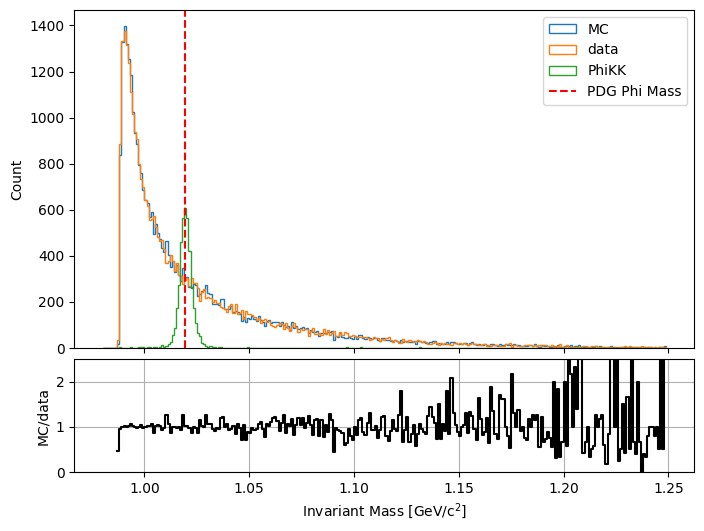

In [10]:
bins = np.arange(0.980, 1.250, 0.001)

mc   = df_combined_study['M'].to_numpy()
data = df_data_study['M'].to_numpy()
phiKK = df_phiKK_study['M'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(mc_counts, data_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(x=1.019461, color='r', linestyle='--', label='PDG Phi Mass')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('MC/data')
ax_bot.set_xlabel('Invariant Mass [GeV/c$^2$]')
ax_bot.set_ylim(0, 2.5)  # adjust as you like
ax_bot.grid(True)

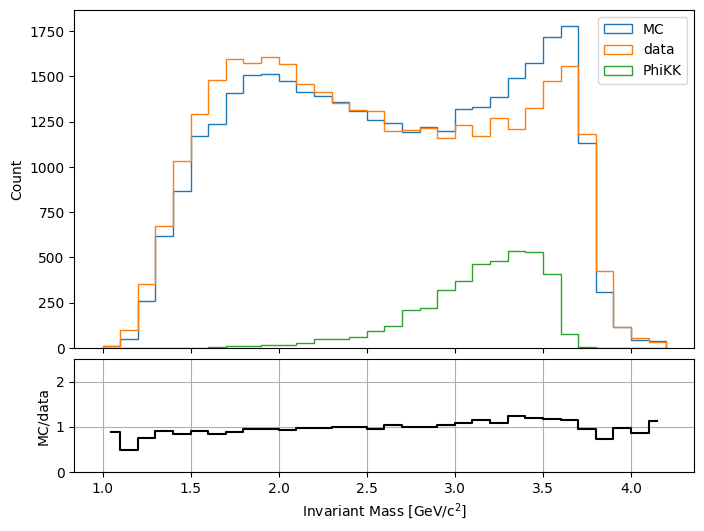

In [11]:
bins = np.arange(1,4.3,0.1)

mc   = df_combined_study['Ptot'].to_numpy()
data = df_data_study['Ptot'].to_numpy()
phiKK = df_phiKK_study['Ptot'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(mc_counts, data_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('MC/data')
ax_bot.set_xlabel('Invariant Mass [GeV/c$^2$]')
ax_bot.set_ylim(0, 2.5)  # adjust as you like
ax_bot.grid(True)

/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_67294/369274545.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(data_counts, mc_counts,


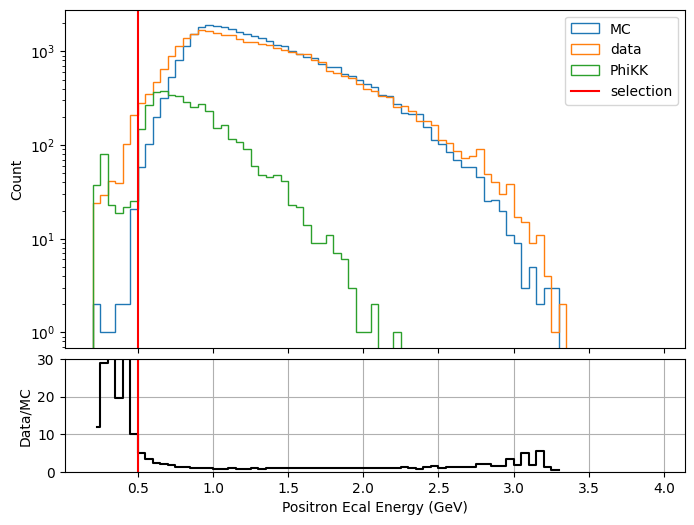

In [12]:
bins = np.arange(.2,4,0.05)

mc   = df_combined_study['pos_E_Ecal'].to_numpy()
data = df_data_study['pos_E_Ecal'].to_numpy()
phiKK = df_phiKK_study['pos_E_Ecal'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['pos_E_Ecal_low'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Ecal Energy (GeV)')
ax_bot.set_ylim(0, 30)
ax_bot.axvline(QualCuts['pos_E_Ecal_low'], color ='red',label="selection")

ax_bot.grid(True)

In [13]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_E_Ecal'] > QualCuts['pos_E_Ecal_low'] )  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_E_Ecal'] > QualCuts['pos_E_Ecal_low'] ) ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_E_Ecal'] > QualCuts['pos_E_Ecal_low'] ) ] ) / len(df_phiKK_study))



MC Eff. =  0.9991481612031489
Data Eff. =  0.9869286805310774
PhiKK Eff. =  0.9493392070484582


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_67294/4146061675.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(data_counts, mc_counts,


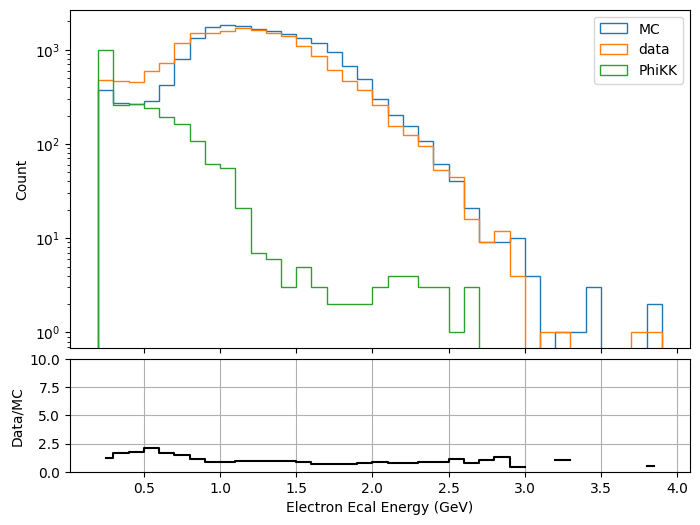

In [14]:

bins = np.arange(.2,4,0.1)

mc   = df_combined_study['ele_E_Ecal'].to_numpy()
data = df_data_study['ele_E_Ecal'].to_numpy()
phiKK = df_phiKK_study['ele_E_Ecal'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Ecal Energy (GeV)')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_67294/2361149122.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(data_counts, mc_counts,


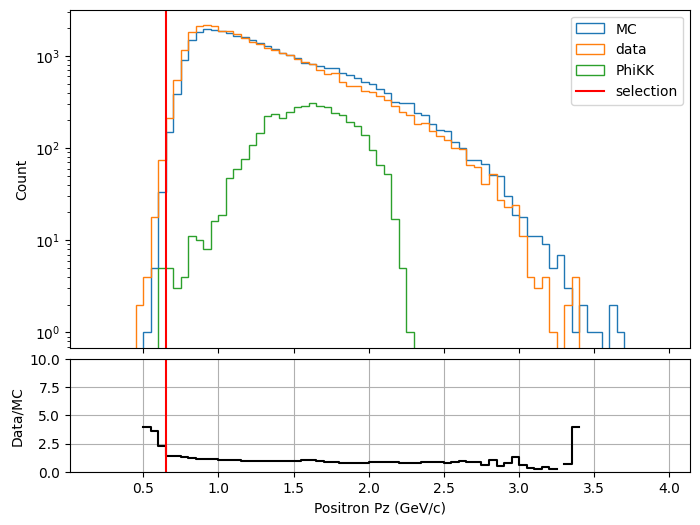

In [15]:
bins = np.arange(.2,4,0.05)

mc   = df_combined_study['pos_Pz'].to_numpy()
data = df_data_study['pos_Pz'].to_numpy()
phiKK = df_phiKK_study['pos_Pz'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['pos_Pz_low'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Pz (GeV/c)')
ax_bot.axvline(QualCuts['pos_Pz_low'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [16]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_Pz'] > QualCuts['pos_Pz_low']) ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_Pz'] > QualCuts['pos_Pz_low']) ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_Pz'] > QualCuts['pos_Pz_low']) ] ) / len(df_phiKK_study))



MC Eff. =  0.9988544236869933
Data Eff. =  0.9971213723416755
PhiKK Eff. =  0.9987763093489965


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_67294/964813115.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(data_counts, mc_counts,


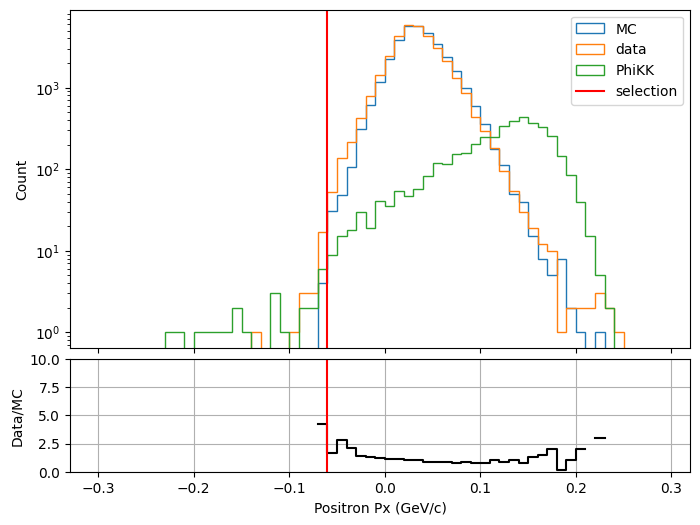

In [17]:
bins = np.arange(-.3,.3,0.01)

mc   = df_combined_study['pos_Px'].to_numpy()
data = df_data_study['pos_Px'].to_numpy()
phiKK = df_phiKK_study['pos_Px'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=data_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['pos_Px_low'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Px (GeV/c)')
ax_bot.axvline(QualCuts['pos_Px_low'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [18]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_Px'] > QualCuts['pos_Px_low'] ) ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_Px'] > QualCuts['pos_Px_low'] )  ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_Px'] > QualCuts['pos_Px_low']) ] ) / len(df_phiKK_study))



MC Eff. =  0.9998825049935378
Data Eff. =  0.999265656209611
PhiKK Eff. =  0.9943710230053843


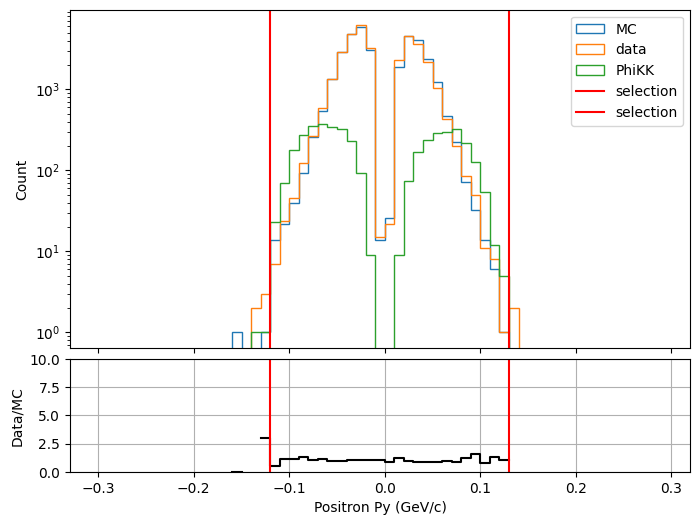

In [19]:
bins = np.arange(-.3,.3,0.01)

mc   = df_combined_study['pos_Py'].to_numpy()
data = df_data_study['pos_Py'].to_numpy()
phiKK = df_phiKK_study['pos_Py'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['pos_Py_low'], color ='red',label="selection")
ax_top.axvline(QualCuts['pos_Py_high'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Py (GeV/c)')
ax_bot.axvline(QualCuts['pos_Py_low'], color ='red',label="selection")
ax_bot.axvline(QualCuts['pos_Py_high'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [20]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_Py'] > QualCuts['pos_Py_low']) & (df_combined_study['pos_Py'] < QualCuts['pos_Py_high'])  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_Py'] > QualCuts['pos_Py_low']) & (df_data_study['pos_Py'] < QualCuts['pos_Py_high'])  ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_Py'] > QualCuts['pos_Py_low']) & (df_phiKK_study['pos_Py'] < QualCuts['pos_Py_high'])  ] ) / len(df_phiKK_study))



MC Eff. =  0.9999412524967689
Data Eff. =  0.9997943837386911
PhiKK Eff. =  0.9995105237395986


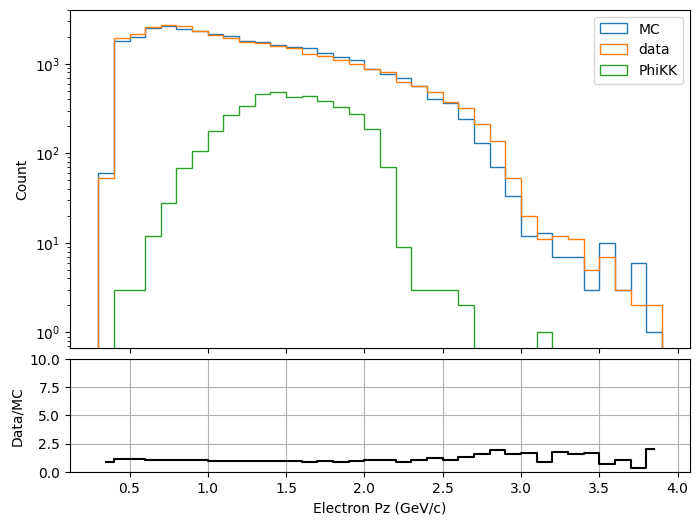

In [21]:

bins = np.arange(.3,4,0.1)

mc   = df_combined_study['ele_Pz'].to_numpy()
data = df_data_study['ele_Pz'].to_numpy()
phiKK = df_phiKK_study['ele_Pz'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Pz (GeV/c)')
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

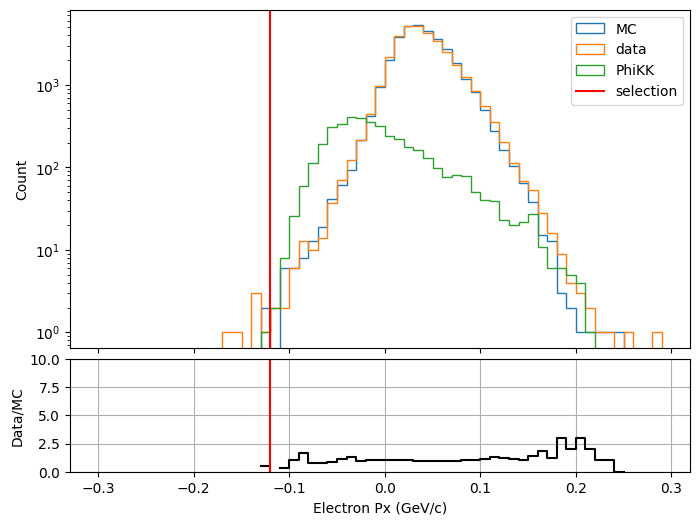

In [22]:
bins = np.arange(-.3,.3,0.01)

mc   = df_combined_study['ele_Px'].to_numpy()
data = df_data_study['ele_Px'].to_numpy()
phiKK = df_phiKK_study['ele_Px'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['ele_Px_low'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Px (GeV/c)')
ax_bot.axvline(QualCuts['ele_Px_low'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [23]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['ele_Px'] > QualCuts['ele_Px_low'])  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['ele_Px'] > QualCuts['ele_Px_low']) ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['ele_Px'] > QualCuts['ele_Px_low'])   ] ) / len(df_phiKK_study))



MC Eff. =  0.9999412524967689
Data Eff. =  0.9998237574903066
PhiKK Eff. =  0.9997552618697993


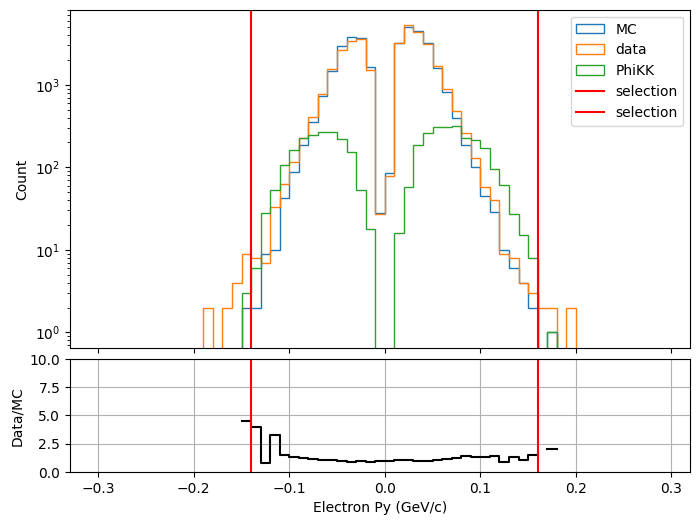

In [24]:
bins = np.arange(-.3,.3,0.01)

mc   = df_combined_study['ele_Py'].to_numpy()
data = df_data_study['ele_Py'].to_numpy()
phiKK = df_phiKK_study['ele_Py'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['ele_Py_low'], color ='red',label="selection")
ax_top.axvline(QualCuts['ele_Py_high'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Py (GeV/c)')
ax_bot.axvline(QualCuts['ele_Py_low'], color ='red',label="selection")
ax_bot.axvline(QualCuts['ele_Py_high'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [25]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['ele_Py'] > QualCuts['ele_Py_low']) & (df_combined_study['ele_Py'] < QualCuts['ele_Py_high'])  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['ele_Py'] > QualCuts['ele_Py_low'] ) & (df_data_study['ele_Py'] < QualCuts['ele_Py_high'])  ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['ele_Py'] > QualCuts['ele_Py_low']) & (df_phiKK_study['ele_Py'] < QualCuts['ele_Py_high'] )  ] ) / len(df_phiKK_study))



MC Eff. =  0.9999118787451533
Data Eff. =  0.9993244037128423
PhiKK Eff. =  0.9990210474791973


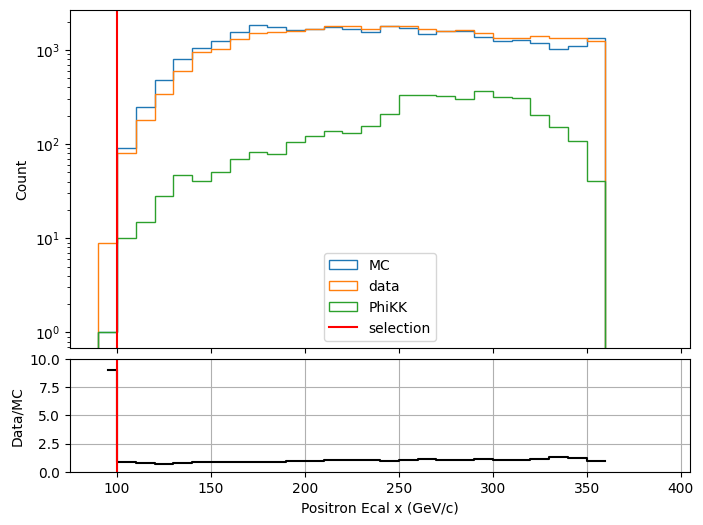

In [26]:
bins = np.arange(90,400,10)

mc   = df_combined_study['pos_Ecal_x'].to_numpy()
data = df_data_study['pos_Ecal_x'].to_numpy()
phiKK = df_phiKK_study['pos_Ecal_x'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['pos_Ecal_x_low'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Ecal x (GeV/c)')
ax_bot.axvline(QualCuts['pos_Ecal_x_low'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [27]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_Ecal_x'] > QualCuts['pos_Ecal_x_low'] )  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_Ecal_x'] > QualCuts['pos_Ecal_x_low'] )  ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_Ecal_x'] > QualCuts['pos_Ecal_x_low'])  ] ) / len(df_phiKK_study))



MC Eff. =  0.9999706262483844
Data Eff. =  0.9996768887322289
PhiKK Eff. =  0.995349975526187


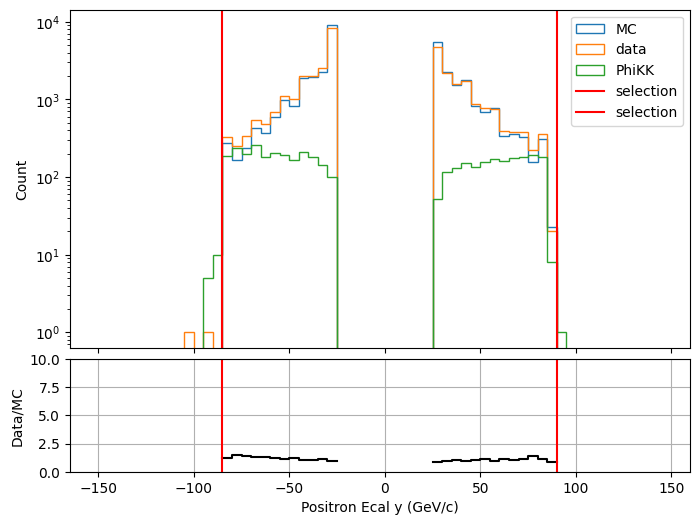

In [28]:
bins = np.arange(-150,150,5)

mc   = df_combined_study['pos_Ecal_y'].to_numpy()
data = df_data_study['pos_Ecal_y'].to_numpy()
phiKK = df_phiKK_study['pos_Ecal_y'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['pos_Ecal_y_low'], color ='red',label="selection")
ax_top.axvline(QualCuts['pos_Ecal_y_high'] , color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Ecal y (GeV/c)')
ax_bot.axvline(QualCuts['pos_Ecal_y_low'], color ='red',label="selection")
ax_bot.axvline(QualCuts['pos_Ecal_y_high'] , color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [29]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_Ecal_y'] > QualCuts['pos_Ecal_y_low']) & (df_combined_study['pos_Ecal_y'] < QualCuts['pos_Ecal_y_high'] )  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_Ecal_y'] > QualCuts['pos_Ecal_y_low'] ) & (df_data_study['pos_Ecal_y'] < QualCuts['pos_Ecal_y_high']  )  ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_Ecal_y'] > QualCuts['pos_Ecal_y_low']) & (df_phiKK_study['pos_Ecal_y'] < QualCuts['pos_Ecal_y_high']  )  ] ) / len(df_phiKK_study))



MC Eff. =  1.0
Data Eff. =  0.9999412524967689
PhiKK Eff. =  0.996084189916789


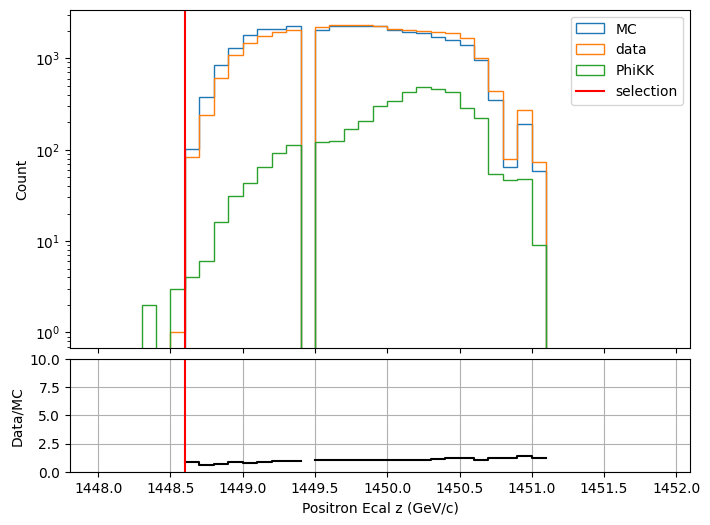

In [30]:
bins = np.arange(1448,1452,.1)

mc   = df_combined_study['pos_Ecal_z'].to_numpy()
data = df_data_study['pos_Ecal_z'].to_numpy()
phiKK = df_phiKK_study['pos_Ecal_z'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['pos_Ecal_z_low'], color ='red',label="selection")
# ax_top.axvline(pos_Ecal_z_lims[1], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Positron Ecal z (GeV/c)')
ax_bot.axvline(QualCuts['pos_Ecal_z_low'], color ='red',label="selection")
# ax_bot.axvline(pos_Ecal_z_lims[1], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [31]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['pos_Ecal_z'] > QualCuts['pos_Ecal_z_low'])  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['pos_Ecal_z'] > QualCuts['pos_Ecal_z_low'])  ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['pos_Ecal_z'] > QualCuts['pos_Ecal_z_low']) ] ) / len(df_phiKK_study))



MC Eff. =  1.0
Data Eff. =  0.9999706262483844
PhiKK Eff. =  0.9987763093489965


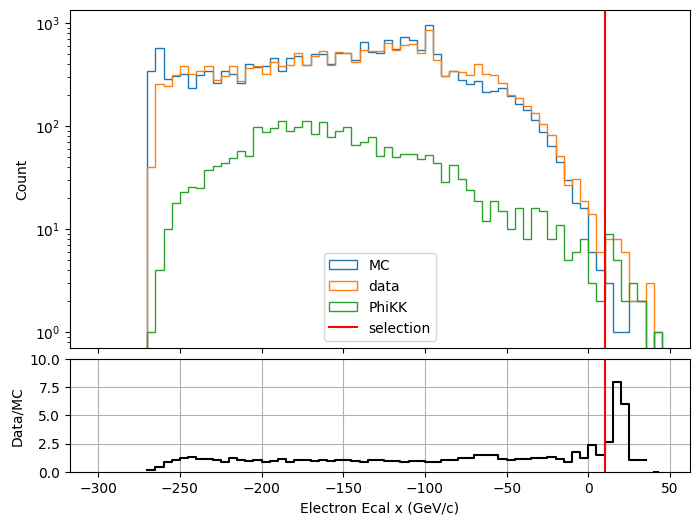

In [32]:
bins = np.arange(-300,50,5)

mc   = df_combined_study['ele_Ecal_x'].to_numpy()
data = df_data_study['ele_Ecal_x'].to_numpy()
phiKK = df_phiKK_study['ele_Ecal_x'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['ele_Ecal_x_high'], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Ecal x (GeV/c)')
#ax_bot.axvline(ele_Ecal_x_lims[0], color ='red',label="selection")
ax_bot.axvline(QualCuts['ele_Ecal_x_high'], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [33]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['ele_Ecal_x'] < QualCuts['ele_Ecal_x_high'])  ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['ele_Ecal_x'] < QualCuts['ele_Ecal_x_high'])  ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['ele_Ecal_x'] < QualCuts['ele_Ecal_x_high'] ) ] ) / len(df_phiKK_study))



MC Eff. =  0.9996768887322289
Data Eff. =  0.9987663024321466
PhiKK Eff. =  0.9877630934899657


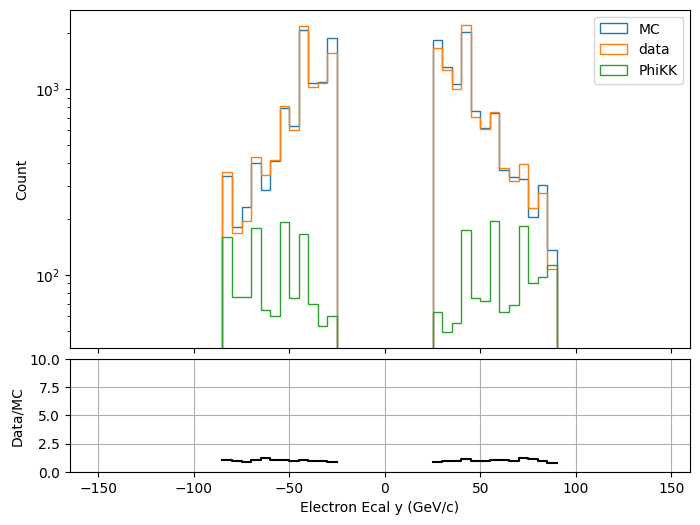

In [34]:

bins = np.arange(-150,150,5)

mc   = df_combined_study['ele_Ecal_y'].to_numpy()
data = df_data_study['ele_Ecal_y'].to_numpy()
phiKK = df_phiKK_study['ele_Ecal_y'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')

ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Ecal y (GeV/c)')

ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

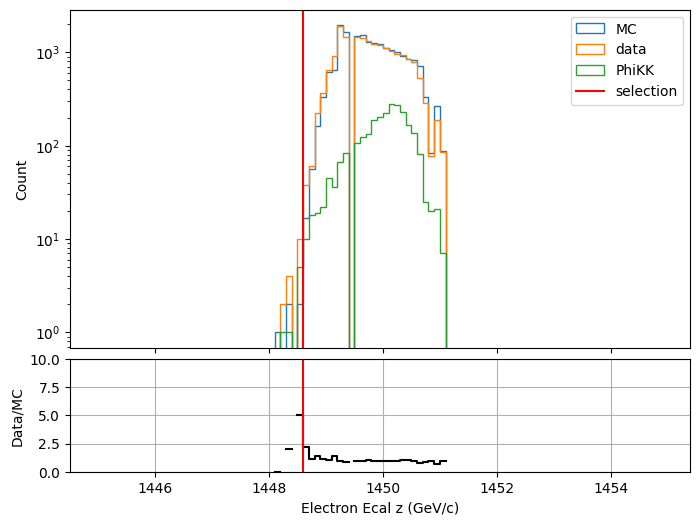

In [35]:
bins = np.arange(1445,1455,.1)

mc   = df_combined_study['ele_Ecal_z'].to_numpy()
data = df_data_study['ele_Ecal_z'].to_numpy()
phiKK = df_phiKK_study['ele_Ecal_z'].to_numpy()

# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts,
                  out=np.full_like(mc_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: same as your plot (normalized shapes) ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, label='MC')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(phiKK, bins=bins, histtype='step', density=False, label='PhiKK')
ax_top.axvline(QualCuts['ele_Ecal_z_low'], color ='red',label="selection")
# ax_top.axvline(ele_Ecal_z_lims[1], color ='red',label="selection")
ax_top.set_yscale('log')
ax_top.set_ylabel('Count')
ax_top.legend()

# --- Bottom: MC/data ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.set_ylabel('Data/MC')
ax_bot.set_xlabel('Electron Ecal z (GeV/c)')
ax_bot.axvline(QualCuts['ele_Ecal_z_low'], color ='red',label="selection")
# ax_bot.axvline(ele_Ecal_z_lims[1], color ='red',label="selection")
ax_bot.set_ylim(0, 10)
ax_bot.grid(True)

In [36]:
print("MC Eff. = ", len(df_combined_study.loc[(df_combined_study['ele_Ecal_z'] > QualCuts['ele_Ecal_z_low']) | (df_combined_study['ele_Ecal_z'] < 0)   ] ) / len(df_combined_study))
print("Data Eff. = ", len(df_data_study.loc[(df_data_study['ele_Ecal_z'] > QualCuts['ele_Ecal_z_low'])  | (df_data_study['ele_Ecal_z'] < 0)   ] ) / len(df_data_study))
print("PhiKK Eff. = ", len(df_phiKK_study.loc[(df_phiKK_study['ele_Ecal_z'] > QualCuts['ele_Ecal_z_low']) | (df_phiKK_study['ele_Ecal_z'] < 0)   ] ) / len(df_phiKK_study))



MC Eff. =  0.9998531312419222
Data Eff. =  0.9995300199741511
PhiKK Eff. =  0.9982868330885952


In [40]:
def getmask(df, QualCuts):
    mask = (
        (df['pos_E_Ecal'] > QualCuts['pos_E_Ecal_low'] ) &
        (df['pos_Pz'] > QualCuts['pos_Pz_low']  ) &
        (df['pos_Px'] > QualCuts['pos_Px_low']  ) &
        (df['pos_Py'] > QualCuts['pos_Py_low'] ) & (df['pos_Py'] < QualCuts['pos_Py_high'] ) &
        (df['ele_Px'] > QualCuts['ele_Px_low'] ) &
        (df['ele_Py'] > QualCuts['ele_Py_low'] ) & (df['ele_Py'] < QualCuts['ele_Py_high'] ) &
        (df['pos_Ecal_x'] > QualCuts['pos_Ecal_x_low'] ) &
        (df['pos_Ecal_y'] > QualCuts['pos_Ecal_y_low'] ) & (df['pos_Ecal_y'] < QualCuts['pos_Ecal_y_high'] ) &
        (df['pos_Ecal_z'] > QualCuts['pos_Ecal_z_low'] ) &
        (df['ele_Ecal_x'] < QualCuts['ele_Ecal_x_high'] ) &
        ((df['ele_Ecal_z'] > QualCuts['ele_Ecal_z_low'] ) | (df['ele_Ecal_z'] < 0))  
    )
    return mask

In [41]:
df_combined_study_1 = df_combined_study.loc[getmask(df_combined_study, QualCuts)]
df_data_study_1 = df_data_study.loc[getmask(df_data_study, QualCuts)]
df_phiKK_study_1 = df_phiKK_study.loc[getmask(df_phiKK_study, QualCuts)]


print(len(df_combined_study_1)/len(df_combined_study))
print(len(df_data_study_1)/len(df_data_study))
print(len(df_phiKK_study_1)/len(df_phiKK_study))

0.9973269886029844
0.9817295264951239
0.9410181106216349


In [42]:
df_FakeGen_1pt05_kaon = df_FakeGen_1pt05_kaon.loc[getmask(df_FakeGen_1pt05_kaon, QualCuts)].reset_index(drop=True)
df_tritrig = df_tritrig.loc[getmask(df_tritrig, QualCuts)].reset_index(drop=True)
df_phiKK = df_phiKK.loc[getmask(df_phiKK, QualCuts)].reset_index(drop=True)
df_wab = df_wab.loc[getmask(df_wab, QualCuts)].reset_index(drop=True)
df_data = df_data.loc[getmask(df_data, QualCuts)].reset_index(drop=True)


In [43]:
df_FakeGen_1pt05_kaon.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_FakeGen_1pt05_kaon_QualCuts.pk')
df_tritrig.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_QualCuts.pk')
df_phiKK.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_QualCuts.pk')
df_wab.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_QualCuts.pk')
df_data.to_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_data_QualCuts.pk')